# 10 — Bootstrap and Resampling Methods
**References:** Efron (1979) · Efron & Tibshirani (1993) *Bootstrap* · Davison & Hinkley (1997)

## Narrative thread
```
Bootstrap principle -> CI methods -> Permutation tests -> Cross-validation
```

## The bootstrap principle (Efron, 1979)

The **plug-in principle:** estimate population quantities by replacing the
unknown distribution $F$ with the empirical distribution $\hat{F}_n$.

The **bootstrap:** use $\hat{F}_n$ to simulate the sampling distribution of any statistic $T$:
1. Draw $B$ samples of size $n$ *with replacement* from $\{x_1,\ldots,x_n\}$
2. Compute $T^{(b)}$ on each bootstrap sample
3. Use the distribution of $\{T^{(b)}\}$ to estimate SE, CI, or bias

**Why does it work?** The relationship between $F$ and $T(X_1,\ldots,X_n)$ mirrors
the relationship between $\hat{F}_n$ and $T(X_1^*,\ldots,X_n^*)$. The bootstrap
world approximates the real world.

## Bootstrap CI methods

| Method | Formula | When |
|---|---|---|
| Normal | $T \pm z_{\alpha/2} \cdot SE_{boot}$ | When $T$ is approximately normal |
| Percentile | $(T^{(\alpha/2)}, T^{(1-\alpha/2)})$ | Simple; can be biased |
| Basic (pivot) | $(2T - T^{(1-\alpha/2)},\; 2T - T^{(\alpha/2)})$ | Corrects for bias |
| BCa | Bias-corrected and accelerated | Best coverage; most complex |

## Permutation test

To test $H_0: F_1 = F_2$ (distributions equal):
1. Compute observed statistic $T_{obs}$ (e.g., $\bar{x}_1 - \bar{x}_2$)
2. For $b = 1,\ldots,B$: shuffle group labels; compute $T^{(b)}$
3. $p = P(|T^{(b)}| \geq |T_{obs}|)$

Exact if you enumerate all permutations; approximate for large $n$.

## Cross-validation

Estimates **out-of-sample** prediction error — how well a model generalizes.

| Method | Description | Bias | Variance |
|---|---|---|---|
| Holdout | Single 80/20 split | High | High |
| $k$-fold CV | $k$ splits; rotate test set | Medium | Medium |
| LOOCV | $n$-fold; leave one out | Low | High |
| Repeated $k$-fold | Average over multiple random splits | Low | Low |

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

Bootstrap CIs for Exponential(3) median  (true=2.0794, n=50)
  Observed median:  1.7184
  Bootstrap SE:     0.4093
  Normal CI:        [0.9161, 2.5208]  covers
  Percentile CI:    [1.0365,    2.4624]  covers
  Basic CI:         [0.9745,  2.4003]  covers



Coverage simulation (500 samples, n=40):
  Normal      : 0.928  (target 0.95)
  Percentile  : 0.932  (target 0.95)
  Basic       : 0.846  (target 0.95)


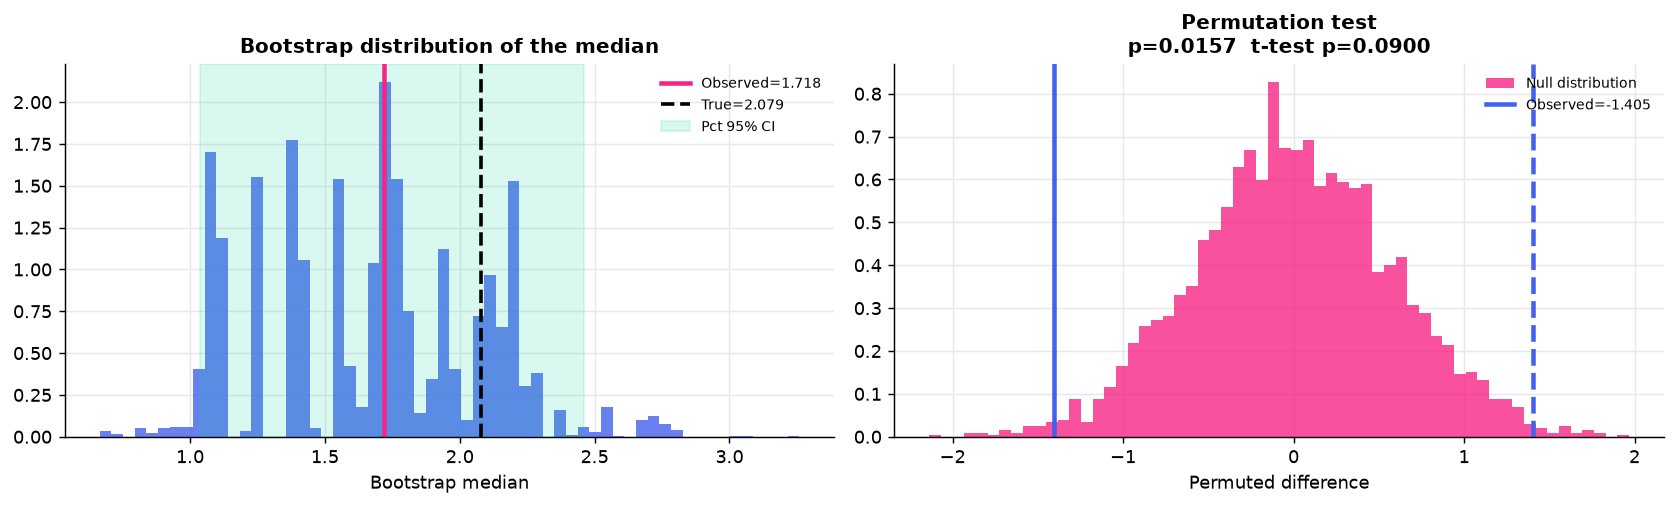

In [2]:
# ── Bootstrap CI for the median ──────────────────────────────────────────
from scipy.stats import expon

np.random.seed(42)
n_bs = 50
x_bs = expon.rvs(scale=3, size=n_bs)   # heavy-tailed: no CLT formula for median
true_median = 3 * np.log(2)

B = 5000
T_obs = np.median(x_bs)
T_boot = np.array([np.median(np.random.choice(x_bs, n_bs, replace=True)) for _ in range(B)])
se_boot = T_boot.std()

# Four CI methods
ci_normal  = (T_obs - 1.96*se_boot, T_obs + 1.96*se_boot)
ci_pct     = (np.percentile(T_boot, 2.5), np.percentile(T_boot, 97.5))
ci_basic   = (2*T_obs - np.percentile(T_boot, 97.5), 2*T_obs - np.percentile(T_boot, 2.5))

print(f'Bootstrap CIs for Exponential(3) median  (true={true_median:.4f}, n={n_bs})')
print(f'  Observed median:  {T_obs:.4f}')
print(f'  Bootstrap SE:     {se_boot:.4f}')
print(f'  Normal CI:        [{ci_normal[0]:.4f}, {ci_normal[1]:.4f}]  {"covers" if ci_normal[0]<=true_median<=ci_normal[1] else "misses"}')
print(f'  Percentile CI:    [{ci_pct[0]:.4f},    {ci_pct[1]:.4f}]  {"covers" if ci_pct[0]<=true_median<=ci_pct[1] else "misses"}')
print(f'  Basic CI:         [{ci_basic[0]:.4f},  {ci_basic[1]:.4f}]  {"covers" if ci_basic[0]<=true_median<=ci_basic[1] else "misses"}')

# Coverage simulation
n_cov, B_cov, B_inner = 40, 500, 1000
covers = {'Normal': 0, 'Percentile': 0, 'Basic': 0}
for _ in range(B_cov):
    samp = expon.rvs(scale=3, size=n_cov)
    T_s  = np.median(samp)
    T_b  = np.array([np.median(np.random.choice(samp, n_cov, replace=True)) for _ in range(B_inner)])
    se_b = T_b.std()
    for method, lo, hi in [
        ('Normal',     T_s - 1.96*se_b,                     T_s + 1.96*se_b),
        ('Percentile', np.percentile(T_b,2.5),               np.percentile(T_b,97.5)),
        ('Basic',      2*T_s - np.percentile(T_b,97.5),      2*T_s - np.percentile(T_b,2.5)),
    ]:
        covers[method] += (lo <= true_median <= hi)
print(f'\nCoverage simulation ({B_cov} samples, n={n_cov}):')
for m, c in covers.items():
    print(f'  {m:<12}: {c/B_cov:.3f}  (target 0.95)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(T_boot, bins=60, color='#4361ee', alpha=0.8, density=True)
axes[0].axvline(T_obs,      color='#f72585', lw=2.5, label=f'Observed={T_obs:.3f}')
axes[0].axvline(true_median, color='black',   lw=2,   linestyle='--', label=f'True={true_median:.3f}')
axes[0].axvspan(*ci_pct, alpha=0.15, color='#06d6a0', label=f'Pct 95% CI')
axes[0].set_xlabel('Bootstrap median'); axes[0].set_title('Bootstrap distribution of the median')
axes[0].legend(fontsize=8)

# Permutation test
g1 = np.random.normal(10, 3, 30)
g2 = np.random.normal(11.5, 3, 30)
T_perm_obs = g1.mean() - g2.mean()
combined = np.concatenate([g1, g2])
T_perm_null = [np.random.permutation(combined)[:30].mean() - np.random.permutation(combined)[:30].mean()
               for _ in range(3000)]
T_perm_null = np.array(T_perm_null)
p_perm = np.mean(np.abs(T_perm_null) >= np.abs(T_perm_obs))

axes[1].hist(T_perm_null, bins=60, color='#f72585', alpha=0.8, density=True, label='Null distribution')
axes[1].axvline(T_perm_obs,  color='#4361ee', lw=2.5, label=f'Observed={T_perm_obs:.3f}')
axes[1].axvline(-T_perm_obs, color='#4361ee', lw=2.5, linestyle='--')
axes[1].set_xlabel('Permuted difference'); axes[1].set_title(f'Permutation test\np={p_perm:.4f}  t-test p={stats.ttest_ind(g1,g2).pvalue:.4f}')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()